# AI Survey Workflows with EDSL
### Week 5 Lab — MACS 30755 1 (Spring 2026) Digital Experiments
Notebook Author: Vera Mao 

---

## What is EDSL?

**EDSL** stands for **Expected Parrot Domain-Specific Language**. It is an open-source Python library that lets you conduct AI-powered surveys and experiments. Instead of paying thousands of dollars to recruit human survey respondents, EDSL lets you:

- Write survey questions exactly as they appear in published studies
- Create AI "agents" that simulate respondents with specific demographic profiles (e.g., a 55-year-old Republican from the South with a high school education)
- Tell the AI which language model to use (GPT-4, Claude, Gemini, etc.)
- Run the full survey and get back structured, analyzable data

**Why does this matter for social science?** Researchers are increasingly using AI to *replicate* or *pre-test* survey findings — checking whether AI agents reproduce the same demographic patterns as human respondents.

---

## How EDSL Works — The Big Picture

There are 5 core objects you need to learn. Think of them like this:

| Object | What it is | Analogy |
|--------|-----------|--------|
| `Question` | A single survey question | One row in a questionnaire |
| `Survey` | A collection of questions | The whole questionnaire |
| `Agent` | A simulated respondent with demographic traits | A survey participant |
| `Model` | The language model that generates answers | The "brain" of the agent |
| `Results` | The collected responses | Your dataset |

The basic workflow is:
```
survey.by(agents).by(models).run() → results
```

---

## Sections in This Notebook

1. [Setup — Installation, API Key & Model](#1.-Setup)
2. [Question Types — Building Your Instrument](#2.-Question-Types)
3. [Surveys — Chaining Multiple Questions](#3-Surveys--chaining-multiple-questions)
4. [Agents — Creating Demographic Personas](#4-agents--creating-demographic-personas)
5. [Running Surveys — The `.by()` Pipeline](#5.-Running-Surveys)
6. [Extracting & Analyzing Results](#6.-Extracting-and-Analyzing-Results)
7. [Complete Assignment Walkthrough — Pew 2024](#7-assignment-walkthrough)
   - [Step 1: Document Your Source](#step-1-source)
   - [Step 2: Human Benchmark](#step-2-benchmark)
   - [Step 3: Agent Design](#step-3-agents)
   - [Step 4: Run the Survey](#step-4-run)
   - [Step 5: Comparison & MAE](#step-5-comparison)
   - [Step 6: Visualize](#step-6-viz)
   - [Step 7: Discussion Template](#step-7-discussion)
8. [References](#8-references)


---
## 1. Setup

### 1.1 Install EDSL

EDSL requires **Python 3.9–3.13**. Install it with pip (or the faster `uv` tool) just like any other library.

> **Note:** If you are running this on your own computer for the first time, uncomment one of the install lines below and run it. On Google Colab, you must always run this cell. On a lab machine where EDSL is pre-installed, you can skip it.


In [2]:
# Install EDSL — uncomment ONE of the lines below if not already installed

# Option A: Standard pip install
# !pip install edsl

# Option B: Recommended — uv is much faster than pip (install uv first: pip install uv)
# !uv pip install edsl -q

# On Google Colab: use Option A (!pip install edsl)


In [3]:
# Verify the installation worked by checking the version
import edsl
print(f"EDSL version: {edsl.__version__}")

EDSL version: 1.0.6


### 1.2 API Key — Using Expected Parrot (Coop)

For this class we use **Expected Parrot's Coop platform** for remote inference. Your survey prompts are sent through Expected Parrot's servers, which have access to all major LLMs (GPT-4o, Claude, Gemini, etc.). You only need **one key** — no separate OpenAI or Anthropic accounts required.

**How to get your Expected Parrot API key:**
1. Sign up for a free account at [expectedparrot.com](https://www.expectedparrot.com) — or run  in a cell to create an account and store your key automatically (easiest option)
2. New accounts receive **in free credits (2,500 credits)** — more than enough for this workshop and the individual assignment

**How credits work:**
- Credits are priced at **\ = 100 credits**
- Cost per run depends on the model and question length, but typical runs use fewer than 10 credits each
- The full Section 8 replication (9 agents, 1 question) costs around 10–20 credits

**Activating remote inference:**
- Log in to [expectedparrot.com](https://www.expectedparrot.com) → go to **Settings** → enable the **Remote Inference** toggle
- Once enabled, all  calls route through Coop automatically

**Security rules:**
- **Never paste your key directly into a shared or submitted notebook**
- Use an environment variable (shown below) or a  file
- On a personal laptop, add it to your shell profile (, )


In [1]:
import os

# ── Option A: Set key directly in this cell ──────────────────────────────────
# (personal use only — do NOT share or submit a notebook with your key in it)
# os.environ["EXPECTED_PARROT_API_KEY"] = "your-key-here"

# ── Option B: Load from a .env file (recommended) ────────────────────────────
# Create a file called .env in the same folder as this notebook containing:
#   EXPECTED_PARROT_API_KEY=your-key-here
# Then uncomment the two lines below:
# from dotenv import load_dotenv  # pip install python-dotenv
# load_dotenv()

# ── Option C: Shell environment (best for local development) ─────────────────
# Add this line to your ~/.bashrc or ~/.zshrc, then restart your terminal:
#   export EXPECTED_PARROT_API_KEY="your-key-here"

# ── Option D: Interactive login (easiest — creates account + stores key) ──────
# from edsl import login
# login()  # Opens a browser, creates/logs in to your Expected Parrot account,
#           # and automatically stores your API key in your environment

# ── Verify the key is set ─────────────────────────────────────────────────────
key = os.getenv("EXPECTED_PARROT_API_KEY")
if key:
    print(f"EXPECTED_PARROT_API_KEY is set ({len(key)} characters)")
    print("Remote inference is enabled — surveys will run on Expected Parrot's servers.")
else:
    print("EXPECTED_PARROT_API_KEY not found.")
    print("Set it using one of the options above before running any surveys.")


EXPECTED_PARROT_API_KEY is set (43 characters)
Remote inference is enabled — surveys will run on Expected Parrot's servers.


### 1.3 Choosing a Model

A `Model` object tells EDSL which language model to use. Through Expected Parrot you have access to all major providers with a single key — no separate OpenAI or Anthropic account needed.

| Model name | Provider | Notes |
|---|---|---|
| `"gpt-4o"` | OpenAI | Good default for replication work |
| `"gpt-4o-mini"` | OpenAI | Cheaper and faster, less capable |
| `"claude-3-5-sonnet-20241022"` | Anthropic | Strong reasoning |
| `"gemini-1.5-flash"` | Google | Fast and cost-effective |

---

#### Single Model vs. Multiple Models

In this workshop we use **one model (GPT-4o)**.

However, EDSL supports running the same survey across **multiple models simultaneously** via `ModelList`. This is useful if you want to compare how different AI systems respond — for example, does GPT-4o produce more accurate demographic variation than Claude?

> **Why we do not require multiple models in this course:**  
> Every additional model multiplies your API costs and doubles the size of your results table. For a homework assignment, one well-chosen model is enough. Use multi-model runs only if your research question explicitly asks *which model best replicates human opinion*.

```python
# ── Multi-model example (optional) ───────────────────────────────────────────
from edsl import Model, ModelList

models = ModelList([
    Model("gpt-4o",                    service_name="openai"),
    Model("gemini-1.5-flash",          service_name="google"),
    Model("claude-3-5-sonnet-20241022", service_name="anthropic"),
])

# Run with multiple models — results will have a "model" column
results = survey.by(agents).by(models).run()

# Filter results by model
gpt_results    = results.filter("model.model == 'gpt-4o'")
claude_results = results.filter("model.model == 'claude-3-5-sonnet-20241022'")
```

The results table will automatically include a `model` column so you can group, filter, and compare across models in your analysis.

---

#### What is Temperature?

**Temperature** is a parameter that controls how *random* or *deterministic* the model's answers are.

Behind the scenes, every time a language model generates a word it computes a confidence score (called a **logit**) for every possible word in its vocabulary. Those scores are then converted into a probability distribution. Temperature controls how this conversion works:

- **Temperature = 0** — The model always picks the single highest-probability word. The output is **completely deterministic**: run the exact same prompt 100 times and you will get the exact same answer every time. 
- **Temperature = 1.0** — The model samples from the original probability distribution. There is genuine randomness: the same prompt can produce different answers on different runs.
- **Temperature > 1.0** — The distribution is flattened, making unlikely words more probable. Answers become more creative (and less reliable).
- **Temperature < 1.0 (but > 0)** — The distribution is sharpened, making the top choice even more dominant. Answers are more conservative.

> **Why does this matter for survey simulation?**  
> At temperature = 0, a model that has learned to associate "Democrat" with marijuana support will answer *Legal for both* **100% of the time**, with zero variance — regardless of how many times you run the survey or how many agents you create. This is a determinism artifact, not a genuine opinion. Raising the temperature (e.g., to 1.0) and using `n > 1` in `.run()` introduces realistic variance and is recommended for replication studies.

```python
# Recommended for survey replication work
m = Model("gpt-4o", temperature=1.0)
results = survey.by(agents).by(m).run(n=3)
```


In [2]:
from edsl import Model, ModelList

# ── Single model (recommended for this workshop) ──────────────────────────────
m = Model("gpt-4o", temperature=1.0)       # temperature=1.0 gives realistic variance
# m = Model("gpt-4o", temperature=0)        # deterministic — same answer every run
# m = Model("claude-3-5-sonnet-20241022")   # Anthropic alternative
# m = Model("gemini-1.5-flash")             # Google alternative

# ── See all available models ──────────────────────────────────────────────────
# print(Model.available())

# ── Test your model with a single question ────────────────────────────────────
from edsl import QuestionFreeText
q = QuestionFreeText(question_name="test", question_text="Say hello in one sentence.")
q.by(m).run(remote_inference_description="model test").select("test").print()

answer.test
Hello! I hope you're having a great day.


### 1.4 Import Everything You Will Need

We import all the EDSL classes we will use in this notebook. Run this cell once at the start of every session — if you restart the kernel you will need to re-run it.

In [4]:
# ── EDSL core classes ────────────────────────────────────────────────────────
from edsl import (
    # ── Question types covered in depth (Sections 2.1–2.5) ──────────────────
    QuestionMultipleChoice,  # Pick exactly one from a list
    QuestionFreeText,        # Open-ended text answer
    QuestionLinearScale,     # Numeric rating scale (e.g., 1–7)
    QuestionYesNo,           # Binary yes/no
    QuestionCheckBox,        # Select all that apply (multi-select)

    # ── Additional question types (see Section 2.6 quick reference) ──────────
    QuestionLikertFive,      # Fixed 5-point agree/disagree Likert scale
    QuestionNumerical,       # Single number answer (with optional min/max)
    QuestionList,            # Response formatted as a list of strings
    QuestionRank,            # Rank options from most to least preferred
    QuestionTopK,            # Pick the top-K items from a list
    QuestionMatrix,          # Battery grid (rows × shared option scale)
    QuestionBudget,          # Allocate a total amount across categories
    QuestionDict,            # Key-value dictionary response
    QuestionExtract,         # Extract structured data matching a template
    QuestionDropdown,        # BM25-powered search through large option sets
    QuestionInterview,       # Multi-turn interview dialogue with an agent
    QuestionFunctional,      # Response generated by a Python function (no LLM)

    # ── Survey container ─────────────────────────────────────────────────────
    Survey,                  # Ordered list of questions with optional skip logic

    # ── Agents (simulated respondents) ───────────────────────────────────────
    Agent,                   # One respondent with demographic traits
    AgentList,               # Collection of multiple agents

    # ── Language models ───────────────────────────────────────────────────────
    Model,                   # A single LLM (e.g., gpt-4o)
    ModelList,               # Run the same survey on multiple models at once

    # ── Scenarios (variable stimuli) ─────────────────────────────────────────
    Scenario,                # One set of placeholder values for {{ }} templates
    ScenarioList,            # Collection of scenarios for batch runs
)

print("EDSL classes loaded successfully.")


EDSL classes loaded successfully.


---
## 2. Question Types

Every EDSL question requires at minimum:
- `question_name` — a Python-valid identifier (no spaces). **This is how you reference the answer later.** Think of it as a variable name for the response.
- `question_text` — the actual survey question, exactly as you want the AI to see it.

Some types also require `question_options` or other parameters (see each subsection).


> **For your assignment:** You need to replicate the exact wording of your chosen survey question. Use `QuestionMultipleChoice` for most GSS/Pew questions with fixed options, `QuestionYesNo` for binary items, or `QuestionLinearScale` for rating scales. The question name you set here becomes the column name in your results (e.g., `answer.your_question_name`).

> **For replication studies:** Use the *exact wording* from the original survey whenever possible. LLMs are sensitive to wording — even small paraphrases can shift response distributions.

### All available question types

| Type | Best for | Returns |
|---|---|---|
| `QuestionMultipleChoice` | Single choice from a fixed list | string (one option) |
| `QuestionYesNo` | Binary attitude items | `"Yes"` or `"No"` |
| `QuestionLinearScale` | Numeric rating scales (1–5, 1–7…) | integer |
| `QuestionFreeText` | Open-ended, qualitative responses | string |
| `QuestionCheckBox` | Select-all-that-apply | list of strings |
| `QuestionLikertFive` | Fixed 5-point agree/disagree scale | string (one of 5 labels) |
| `QuestionNumerical` | Single number (age, count, percent…) | number |
| `QuestionList` | Enumeration of items | list of strings |
| `QuestionRank` | Ordered ranking of options | list (ranked) |
| `QuestionTopK` | Pick the best *k* from a set | list of k strings |
| `QuestionMatrix` | Grid of sub-questions (same scale) | dict of sub-answers |
| `QuestionBudget` | Allocate a total across categories | dict of amounts |
| `QuestionExtract` | Pull structured data from text | dict matching a template |
| `QuestionDict` | Key-value dictionary response | dict |

Sections 2.1–2.5 cover the five types most commonly used in GSS/Pew replication work. Section 2.6 shows brief examples of the remaining types.

### 2.1 Multiple Choice (`QuestionMultipleChoice`)

Use this for any question where respondents pick exactly one option from a fixed list — party identification, policy preferences, frequency scales, etc.


In [5]:
# This replicates the GSS "PARTYID" question (simplified)
# Source: NORC General Social Survey, variable PARTYID
# See: https://gssdataexplorer.norc.org/variables/141/vshow

q_party = QuestionMultipleChoice(
    question_name="party_id",     # We will use this name to filter/select this answer later
    question_text=(
        "Generally speaking, do you usually think of yourself as a "
        "Republican, Democrat, Independent, or what?"
    ),
    question_options=[
        "Strong Democrat",
        "Not very strong Democrat",
        "Independent, close to Democrat",
        "Independent",
        "Independent, close to Republican",
        "Not very strong Republican",
        "Strong Republican",
        "Other party"
    ]
)

# .run() with no arguments sends the question to the default model with no agent persona.
# This is useful for quickly testing that your question is well-formed.
print("Running a quick test (no agent, default model)...")
result = q_party.run()

# .select() chooses which columns to display from the results object
# The column name is always the question_name we set above
result.select("party_id").print()

Running a quick test (no agent, default model)...


answer.party_id
Independent


**What just happened?** EDSL sent a prompt to the default language model saying, in effect: "Please answer this survey question and return exactly one of the listed options." The model answered as itself — no demographic persona assigned yet. We will add agents in Section 4.

### 2.2 Yes / No (`QuestionYesNo`)

Perfect for binary attitude items — the most common format in GSS and Pew replication targets. The model returns either `"Yes"` or `"No"` as a string (no free-form text).

In [6]:
# This replicates the GSS "GRASS" question — marijuana legalization
# Source: NORC General Social Survey, variable GRASS
# See: https://gssdataexplorer.norc.org/variables/285/vshow
# Human benchmark (GSS 2022): ~70% of adults said "Yes" (support legalization)
# Partisan breakdown: Democrats ~76%, Independents ~62%, Republicans ~44%

q_marijuana = QuestionYesNo(
    question_name="marijuana_legal",
    question_text="Do you think the use of marijuana should be made legal or not?"
)

# Quick test
result = q_marijuana.run()
result.select("marijuana_legal").print()

# The returned value is always the string "Yes" or "No"
# This makes it easy to compute percentages:
#   (df["answer.marijuana_legal"] == "Yes").mean() * 100

answer.marijuana_legal
Yes


### 2.3 Linear Scale (`QuestionLinearScale`) — Likert-Style Ratings

Use this whenever the original survey uses a numeric rating scale (1–5, 1–7, confidence ratings, etc.). You can provide labels for the anchor points (lowest and highest values) using the `option_labels` dictionary.

In [7]:
# This replicates the GSS confidence-in-institutions battery
# Source: NORC General Social Survey, variable CONLEGIS (confidence in Congress)
# See: https://gssdataexplorer.norc.org/variables/459/vshow
# The original GSS uses 3 categories; here we expand to a 5-point scale for richer data

q_confidence = QuestionLinearScale(
    question_name="confidence_congress",
    question_text=(
        "I am going to name some institutions in this country. "
        "As far as the people running these institutions are concerned, "
        "would you say you have a great deal of confidence, only some confidence, "
        "or hardly any confidence at all in them? — Congress"
    ),
    question_options=[1, 2, 3, 4, 5],  # The numeric scale values
    option_labels={
        1: "Hardly any confidence",  # Low anchor
        3: "Only some confidence",   # Midpoint label
        5: "A great deal of confidence"  # High anchor
    }
    # You do not need to label every point — just the anchors you want to communicate
)

result = q_confidence.run()
result.select("confidence_congress").print()  # Will return an integer (1–5)

answer.confidence_congress
1


### 2.4 Free Text (`QuestionFreeText`) — Open-Ended Answers

This asks the model to respond in its own words with no constraints. Good for open-ended GSS items like "most important problem" or for asking agents to explain their reasoning after a multiple-choice answer.

In [7]:
# This replicates the GSS "NATPROB" / "MOSTIMPT" type question
# Source: NORC General Social Survey — Most Important Problem
# Note: Free text responses are harder to quantify than closed-ended items;
# plan to use content analysis or topic modeling when comparing to human data.

q_problem = QuestionFreeText(
    question_name="most_important_problem",
    question_text=(
        "What do you think is the most important problem facing the country today? "
        "Please be specific and limit your answer to one sentence."
    )
    # The instruction at the end ("one sentence") helps control response length
)

result = q_problem.run()
result.select("most_important_problem").print()

answer.most_important_problem
"The most important problem facing the country today is the growing political polarization, which undermines effective governance and impedes collaborative solutions to critical issues like climate change, healthcare, and economic inequality."


### 2.5 Checkbox (`QuestionCheckBox`) — Select All That Apply

Use this for multi-select survey items. The model returns a list of the selected options. The `min_selections` and `max_selections` parameters let you constrain how many the model picks.

In [8]:
# This replicates a Pew Research media consumption question
# Source: Pew Research Center — News Platform Fact Sheet (2023)
# See: https://www.pewresearch.org/journalism/fact-sheet/news-platform-fact-sheet/
# Human benchmark: TV (~66%), online news (~86%), social media (~50%) among US adults

q_news = QuestionCheckBox(
    question_name="news_sources",
    question_text=(
        "Where do you regularly get news about politics and current events? "
        "Select all that apply."
    ),
    question_options=[
        "Television",
        "Online news websites or apps",
        "Social media (Facebook, X/Twitter, etc.)",
        "Print newspapers or magazines",
        "Radio",
        "Podcasts",
        "Search",
        "Email newsletters",
        "AI chatbots"
    ],
    min_selections=1,  # Must pick at least one
    max_selections=9   # Can pick all
)

result = q_news.run()
result.select("news_sources").print()  # Returns a list of selected options

answer.news_sources
"['Television', 'Online news websites or apps', 'Social media (Facebook, X/Twitter, etc.)', 'Print newspapers or magazines', 'Radio', 'Podcasts', 'Search', 'Email newsletters', 'AI chatbots']"


### 2.6 Additional Question Types — Quick Reference

The five types above cover most GSS/Pew replication scenarios. EDSL has 12 more types — the full list is at [docs.expectedparrot.com/en/latest/questions](https://docs.expectedparrot.com/en/latest/questions). The most useful ones for survey replication:

```python
# ── QuestionLikertFive — agree/disagree format  ─────────
q = QuestionLikertFive(
    question_name="climate_concern",
    question_text="Climate change is one of the most pressing issues facing humanity.",
    question_options=["Strongly Disagree", "Disagree", "Neither", "Agree", "Strongly Agree"]
)

# ── QuestionNumerical — asks for a number ─────────────────────────────────────
q = QuestionNumerical(
    question_name="approve_pct",
    question_text="What percentage of Americans approve of Congress's performance?",
    min_value=0, max_value=100
)

# ── QuestionMatrix — battery questions (same scale, multiple items) ───────────
# Ideal for GSS confidence-in-institutions series
q = QuestionMatrix(
    question_name="confidence_battery",
    question_text="How much confidence do you have in each institution?",
    question_items=["Congress", "The Supreme Court", "The Military"],
    question_options=["A great deal", "Only some", "Hardly any"]
)

# ── QuestionRank — rank items from most to least preferred ────────────────────
q = QuestionRank(
    question_name="priority_rank",
    question_text="Rank these policy areas from most to least important to you.",
    question_options=["Healthcare", "Economy", "Climate", "Immigration", "Education"],
    num_selections=5
)

# ── QuestionList — ask for a list of items ────────────────────────────────────
q = QuestionList(
    question_name="top_issues",
    question_text="List the three most important problems facing the United States today.",
    max_list_items=3
)
```


---
## 3. Surveys — Chaining Multiple Questions

A `Survey` is an ordered sequence of questions. By default, all questions are asked independently — the model does not "remember" earlier answers when answering later ones. But EDSL gives you two powerful tools to change this:

1. **Answer piping** (`{{ question_name.answer }}`): Insert a prior answer directly into a later question's text — just like conditional question wording in real surveys.
2. **Skip rules** (`.add_skip_rule()`): Conditionally skip a question based on prior answers — like branching logic in Qualtrics.

### 3.1 Basic Multi-Question Survey with Answer Piping

In [9]:
# Question 1: Attitude on gun control
# Common question wording used in Gallup and Pew gun control surveys
# (For GSS gun data, see GUNLAW at https://gssdataexplorer.norc.org/variables/272/vshow)
q_guns = QuestionMultipleChoice(
    question_name="gun_control",
    question_text=(
        "In general, do you feel that the laws covering the sale of firearms "
        "should be made more strict, less strict, or kept as they are now?"
    ),
    question_options=["More strict", "Less strict", "Kept as they are"]
)

# Question 2: Follow-up reasoning (uses answer piping)
# The {{ gun_control.answer }} syntax inserts whatever q1 returned into q2's text.
# When the model sees q2, it will read: "You said gun laws should be 'More strict'. Why..."
q_guns_reason = QuestionFreeText(
    question_name="gun_control_reason",
    question_text=(
        "You said gun laws should be '{{ gun_control.answer }}'. "
        "Briefly, why do you feel that way? (One sentence only.)"
    )
)

# Assemble the survey — questions are asked IN ORDER as they are listed in the Survey() constructor
gun_survey = Survey(questions=[q_guns, q_guns_reason])

# Run it
result = gun_survey.run()

# Select both columns to see how q2 is conditioned on q1's answer
result.select("gun_control", "gun_control_reason").print()

KeyboardInterrupt: 

### 3.1.1 Do I need to list all questions in `Survey(questions=[...])`?

Yes, but not always in a long, messy way.

In EDSL, the `Survey(questions=[...])` line tells the system which questions belong in the survey and in what order they should be asked. If a question is not included, it will not be part of the survey.

For a small survey, it is completely fine to list each question directly:

```python
survey = Survey(questions=[q1, q2, q3, q4])
```

This means the survey will ask q1 first, then q2, then q3, then q4.

For a larger survey, you usually should not put every question into one very long list by hand. A cleaner approach is to group questions into sections, then combine those sections when building the survey.

```python
demographic_questions = [q_age, q_gender, q_education]
attitude_questions = [q_confidence, q_trust, q_satisfaction]
behavior_questions = [q_vote, q_participation]

survey = Survey(
    questions=demographic_questions + attitude_questions + behavior_questions
)
```
This is easier to read and easier to maintain.

Key idea: You do need to include all the questions you want the survey to ask. However, that does not mean you must write them all in one long list manually.

A good rule is:
* If the survey is short, list the questions directly.
* If the survey is long, group questions into sections.

### 3.2 Survey with Skip Rules (Branching Logic)

Skip rules let you replicate survey branching — a common feature in real questionnaires ("If YES, go to Q5; if NO, skip to Q8"). The skip rule takes a Python expression that evaluates to True/False based on prior answers.

In [11]:
# A realistic example: only ask WHY someone is not registered if they said they are not registered

q_registered = QuestionYesNo(
    question_name="registered_voter",
    question_text="Are you currently registered to vote?"
)

q_not_registered_reason = QuestionFreeText(
    question_name="not_registered_reason",
    question_text="What is the main reason you are not registered to vote?"
)

# Build the survey and add the skip rule:
# "Skip q_not_registered_reason if registered_voter == 'Yes'"
# In other words: only ask the follow-up to people who said they are NOT registered.
branching_survey = (
    Survey([q_registered, q_not_registered_reason])
    .add_skip_rule(
        q_not_registered_reason,           # The question to potentially skip
        "registered_voter == 'Yes'"         # Skip if this is True
    )
)

result = branching_survey.run()
# If the model answered 'Yes', not_registered_reason will be None
result.select("registered_voter", "not_registered_reason").print()

/opt/anaconda3/lib/python3.12/site-packages/edsl/surveys/rules/rule.py:169: UserWarning: This uses the old syntax! Converting to Jinja2 style with { }.
Old expression: registered_voter == 'Yes'
New expression: {{ registered_voter.answer }} == 'Yes'
  warnings.warn(


answer.registered_voter,answer.not_registered_reason
Yes,None


---
## 4. Agents — Creating Demographic Personas

This is the **most important section for your replication assignment**.

An `Agent` is an AI entity whose responses are shaped by the `traits` dictionary you provide. When EDSL runs a survey, it prepends a system prompt to the model that describes these traits — essentially telling the LLM: *"You are a [Democrat/Republican/Independent] who is [age group], with [education level]..."*

**The goal:** Your agents' trait distributions should mirror the demographic cells in the paper you are replicating. If the GSS sample is 29% Democrat, 27% Republican, and 44% Independent, your agent pool should reflect those proportions.

> **Important naming convention:** Use the same trait names consistently because they will become column names in your results DataFrame. For example, `party` will appear as `agent.party` in the output.

### 4.1 Creating a Single Agent

> **For your assignment:** You need to build a demographic grid that approximates the sample in your chosen survey. If the original survey reports results by party × age group, create agents for each cell of that grid. Section 4.3 shows how to weight agents to match the actual sample proportions.


In [12]:
# A detailed demographic persona matching a specific GSS respondent profile
# Traits can be any key-value pairs — choose names that match the paper's demographic breakdown

agent_young_democrat = Agent(
    traits={
        "party_affiliation": "Democrat",          # From GSS PARTYID variable
        "age_group": "18-34",                     # From GSS AGE (recoded into groups)
        "education": "college graduate",           # From GSS EDUC (recoded)
        "region": "Northeast",                     # From GSS REGION
        "gender": "female",                        # From GSS SEX
        "race_ethnicity": "White, non-Hispanic"   # From GSS RACECEN1
    }
)

# Preview: see the agent's traits
print("Agent traits:")
print(agent_young_democrat)

# Quick test: ask just one question to this single agent
result = q_marijuana.by(agent_young_democrat).run()
result.select("party_affiliation", "marijuana_legal").print()

Agent traits:
Agent(traits = {'party_affiliation': 'Democrat', 'age_group': '18-34', 'education': 'college graduate', 'region': 'Northeast', 'gender': 'female', 'race_ethnicity': 'White, non-Hispanic'})


agent.party_affiliation,answer.marijuana_legal
Democrat,Yes


### 4.2 Building an `AgentList` with a Demographic Grid

For replication, you need many agents — one (or more) for each demographic cell in your comparison. Python's list comprehension makes this concise. 

**Think of each cell** in the demographic grid as one agent. If you have 3 parties × 3 age groups × 4 education levels, that is 36 cells = 36 agents.

In [15]:
# Example: Create a party × age group grid of agents
# These 9 cells correspond to a common GSS demographic breakdown
# References:
#   Party distribution (GSS 2022): Democrats ~29%, Independents ~44%, Republicans ~27%
#   Age distribution varies by question — check the specific table in the codebook

parties    = ["Democrat", "Republican", "Independent"]
age_groups = ["18-34", "35-54", "55+"]

# This creates one agent per combination — 3 × 3 = 9 total
# In a real replication you would create more agents per cell to match sample sizes
agent_grid = AgentList(
    Agent(
        traits={
            "party": party,        # Will appear as "agent.party" in results
            "age_group": age       # Will appear as "agent.age_group" in results
        }
    )
    for party in parties
    for age in age_groups
)

print(f"Total agents created: {len(agent_grid)}")

# Preview the first few agents
for i, agent in enumerate(agent_grid[:4]):
    print(f"  Agent {i+1}: {agent.traits}")

Total agents created: 9
  Agent 1: {'party': 'Democrat', 'age_group': '18-34'}
  Agent 2: {'party': 'Democrat', 'age_group': '35-54'}
  Agent 3: {'party': 'Democrat', 'age_group': '55+'}
  Agent 4: {'party': 'Republican', 'age_group': '18-34'}


### 4.3 What if I Know the Proportions but Not the Exact Counts?

Sometimes a published report gives you **percentages** (e.g., "60% female, 40% male") but not the raw cell counts. In that case, pick a reasonable total `N` for your simulation and convert proportions into counts automatically.

The helper code below handles multi-level demographic grids — for example, gender × age — without requiring you to do the arithmetic by hand.

In [10]:
from collections import Counter

total_n = 100   # choose your simulation size

# Step 1: overall gender proportions
gender_props = {
    "Female": 0.60,
    "Male":   0.40
}

# Step 2: conditional age proportions within each gender
age_props_within_gender = {
    "Female": {"18-29": 0.50, "30-49": 0.30, "50+": 0.20},
    "Male":   {"18-29": 0.25, "30-49": 0.35, "50+": 0.40}
}

# Convert proportions into agent counts
agents = []
for gender, g_prop in gender_props.items():
    gender_n = round(total_n * g_prop)
    prefix = "f" if gender == "Female" else "m"
    for age_group, age_prop in age_props_within_gender[gender].items():
        cell_n = round(gender_n * age_prop)
        for i in range(cell_n):
            agents.append(
                Agent(traits={
                    "gender":     gender,
                    "age_group":  age_group,
                    "persona_id": f"{prefix}_{age_group}_{i+1}"
                })
            )

weighted_agents = AgentList(agents)
print(f"Total agents created: {len(weighted_agents)}")

# Verify distribution
dist = Counter((a.traits["gender"], a.traits["age_group"]) for a in weighted_agents)
print("\nGender × Age distribution:")
for (gender, age), count in sorted(dist.items()):
    print(f"  {gender} / {age}: {count} agents ({count/len(weighted_agents)*100:.0f}%)")

Total agents created: 100

Gender × Age distribution:
  Female / 18-29: 30 agents (30%)
  Female / 30-49: 18 agents (18%)
  Female / 50+: 12 agents (12%)
  Male / 18-29: 10 agents (10%)
  Male / 30-49: 14 agents (14%)
  Male / 50+: 16 agents (16%)


### 4.3.1 What if I Have the Exact Participant Counts?

If the paper reports exact sample sizes per cell — or gives you the total N plus percentages — **create exactly that many agents**, one per participant. This is the most faithful replication approach: a 1,000-person survey becomes 1,000 agents.

Use this when you want to match not just the proportions but the actual sample size of the original study.

In [11]:
# Exact counts taken directly from the paper
# Example: Pew 2024 marijuana survey (N = 1,000, approximate cell sizes)
# Replace the numbers below with the actual figures from your study.

exact_counts = {
    # (party,            age_group) : n_participants
    ("Rep/Lean Rep",     "18-29")   : 53,
    ("Rep/Lean Rep",     "30-49")   : 95,
    ("Rep/Lean Rep",     "50-64")   : 112,
    ("Rep/Lean Rep",     "65+")     : 90,
    ("Dem/Lean Dem",     "18-29")   : 88,
    ("Dem/Lean Dem",     "30-49")   : 142,
    ("Dem/Lean Dem",     "50-64")   : 130,
    ("Dem/Lean Dem",     "65+")     : 90,
    # add more cells as needed ...
}

# Build one agent per participant
agents = []
for (party, age_group), n in exact_counts.items():
    for i in range(n):
        agents.append(
            Agent(traits={
                "party":      party,
                "age_group":  age_group,
                "persona":    f"You are a {age_group}-year-old who identifies as {party}.",
                "persona_id": f"{party.replace('/', '_')}_{age_group}_{i+1}"
            })
        )

exact_agents = AgentList(agents)
print(f"Total agents: {len(exact_agents)}  (should match your paper's N)")

# Verify
from collections import Counter
dist = Counter((a.traits["party"], a.traits["age_group"]) for a in exact_agents)
print("\nParty × Age cell sizes:")
for (party, age), count in sorted(dist.items()):
    print(f"  {party} / {age}: {count}")

Total agents: 800  (should match your paper's N)

Party × Age cell sizes:
  Dem/Lean Dem / 18-29: 88
  Dem/Lean Dem / 30-49: 142
  Dem/Lean Dem / 50-64: 130
  Dem/Lean Dem / 65+: 90
  Rep/Lean Rep / 18-29: 53
  Rep/Lean Rep / 30-49: 95
  Rep/Lean Rep / 50-64: 112
  Rep/Lean Rep / 65+: 90


---
## 5. Running Surveys

The central syntax in EDSL is the **chained `.by()` call** followed by `.run()`:

```python
results = survey.by(agents).by(models).run()
```

Here is what this does step by step:
1. `survey` — your collection of questions
2. `.by(agents)` — ask every question to every agent (cross-product)
3. `.by(models)` — do this for every model (another cross-product)
4. `.run()` — send all the prompts to the APIs (runs in parallel), collect responses

**Result count formula:** `n_agents × n_models × n_scenarios` rows in your results.

> **For your assignment:** You will run one survey with a grid of demographic agents and one model. The `remote_inference_description` parameter labels your job in the Coop dashboard so you can find it later.

> **Caching:** EDSL automatically caches every API response. If you re-run the same survey with the same configuration, the second run retrieves cached results — no extra API cost.

### 5.1 Minimal Run — Single Question, No Agent


In [12]:
# The simplest possible run: one question, default model, no persona
# Use this to check that a question is correctly formatted before scaling up

q_trust = QuestionMultipleChoice(
    question_name="trust_govt",
    question_text=(
        "How often can you trust the federal government in Washington to do what is right? "
        "Would you say just about always, most of the time, only some of the time, or never?"
    ),
    question_options=["Just about always", "Most of the time", "Only some of the time", "Never"]
    # Source: American National Election Studies (ANES) trust in government question
    # See: https://electionstudies.org/resources/anes-guide/top-tables/?id=098
)

# remote_inference_description labels this job in your Coop account dashboard
result = q_trust.run(remote_inference_description="Section 6.1 — trust question test")
result.select("trust_govt").print()

answer.trust_govt
Only some of the time


### 5.2 Run with Agents and a Specific Model

In [13]:
# Three party-identified agents respond to the trust question
# We expect Democrats and Republicans to give different answers — does the AI reproduce this?

# Real-world benchmark for comparison:
# ANES 2020 shows trust in government differs significantly by party
# Source: Hetherington, M. & Rudolph, T. (2015). Why Washington Won't Work. University of Chicago Press.

party_agents = AgentList([
    Agent(traits={"party": "Democrat"}),
    Agent(traits={"party": "Republican"}),
    Agent(traits={"party": "Independent"}),
])

trust_survey = Survey(questions=[q_trust])

results = (
    trust_survey
    .by(party_agents)          # Ask each of the 3 agents
    .by(Model("gpt-4o"))       # Use GPT-4o via remote inference
    .run(remote_inference_description="Section 6.2 — trust by party")  # tags the job in Coop
)

results.select("party", "trust_govt").print()

agent.party,answer.trust_govt
Democrat,Only some of the time
Republican,Only some of the time
Independent,Only some of the time


### 5.3 Full Pipeline — Survey × Agent Grid × Multiple Models

In [14]:
# Two-question marijuana survey
# Question 1: The GSS GRASS yes/no item (our primary replication target)
# Question 2: A Likert-style follow-up on perceived harm

q_legal = QuestionYesNo(
    question_name="marijuana_legal",
    question_text="Do you think the use of marijuana should be made legal or not?"
)

q_harm = QuestionLinearScale(
    question_name="marijuana_harm",
    question_text="How harmful to society do you think marijuana use is?",
    question_options=[1, 2, 3, 4, 5],
    option_labels={1: "Not at all harmful", 3: "Moderately harmful", 5: "Extremely harmful"}
)

two_q_survey = Survey(questions=[q_legal, q_harm])

# 3 parties × 3 age groups = 9 demographic cells
demographic_agents = AgentList(
    Agent(traits={"party": party, "age_group": age})
    for party in ["Democrat", "Republican", "Independent"]
    for age in ["18-34", "35-54", "55+"]
)

# Run via remote inference — 9 agents × 1 model = 9 API calls, run in parallel
full_results = (
    two_q_survey
    .by(demographic_agents)
    .by(Model("gpt-4o"))
    .run(remote_inference_description="Section 5.3 — marijuana survey full pipeline")
)

print(f"Total result rows: {len(full_results)}  (expected: 9 agents × 1 model = 9)")
full_results.select("party", "age_group", "marijuana_legal", "marijuana_harm").print()

Total result rows: 9  (expected: 9 agents × 1 model = 9)


agent.party,agent.age_group,answer.marijuana_legal,answer.marijuana_harm
Democrat,18-34,Yes,1
Democrat,35-54,Yes,2
Democrat,55+,Yes,2
Republican,18-34,Yes,3
Republican,35-54,No,3
Republican,55+,No,3
Independent,18-34,Yes,2
Independent,35-54,Yes,2
Independent,55+,Yes,2


---
## 6. Extracting and Analyzing Results

The `Results` object returned by `.run()` has built-in methods for quick inspection. But for real analysis, you will convert it to a **Pandas DataFrame** and use standard data science tools.

**Column naming in the DataFrame:**
- `agent.{trait_name}` — demographic traits (e.g., `agent.party`, `agent.age_group`)
- `answer.{question_name}` — question responses (e.g., `answer.marijuana_legal`)
- `comment.{question_name}_comment` — model's comment on its answer (if enabled)
- `model.model` — which LLM was used
- `scenario.{key}` — scenario variable values
- `raw_model_response.{question_name}_cost` — per-question API cost

**Tip:** Call `results.show_columns()` to see the full list of available columns in your results object.

### 6.1 Built-in Results Methods

> **For your assignment:** After running your survey, convert results to a Pandas DataFrame with `.to_pandas()`, then compute response rates by demographic group (e.g., % who said "Yes" by party). Section 6.3 shows how to build the side-by-side bar chart required for Section 2 of the report.


In [18]:
# ── show available columns ───────────────────────────────────────────────
full_results.show_columns()

print("\n" + "─"*60 + "\n")

# ── select ───────────────────────────────────────────────────────────────
display(
    full_results.select("party", "age_group", "marijuana_legal").to_pandas()
)

print("\n" + "─"*60 + "\n")

# ── filter ───────────────────────────────────────────────────────────────
display(
    full_results.filter("party == 'Democrat'")
    .select("age_group", "marijuana_legal", "marijuana_harm")
    .to_pandas()
)

print("\n" + "─"*60 + "\n")

# ── sort_by ──────────────────────────────────────────────────────────────
display(
    full_results.sort_by("party", "age_group")
    .select("party", "age_group", "marijuana_harm")
    .to_pandas()
)

print("\n" + "─"*60 + "\n")

# ── sample ───────────────────────────────────────────────────────────────
display(
    full_results.sample(3)
    .select("party", "marijuana_legal")
    .to_pandas()
)

print("\n" + "─"*60 + "\n")

# ── shuffle ──────────────────────────────────────────────────────────────
display(
    full_results.shuffle()
    .select("party", "marijuana_legal")
    .to_pandas()
)


────────────────────────────────────────────────────────────



,agent.party,agent.age_group,answer.marijuana_legal
0,Democrat,18-34,Yes
1,Democrat,35-54,Yes
2,Democrat,55+,Yes
3,Republican,18-34,Yes
4,Republican,35-54,No
5,Republican,55+,No
6,Independent,18-34,Yes
7,Independent,35-54,Yes
8,Independent,55+,Yes



────────────────────────────────────────────────────────────



,agent.age_group,answer.marijuana_legal,answer.marijuana_harm
0,18-34,Yes,2
1,35-54,Yes,2
2,55+,Yes,2



────────────────────────────────────────────────────────────



,agent.party,agent.age_group,answer.marijuana_harm
0,Democrat,18-34,2
1,Democrat,35-54,2
2,Democrat,55+,2
3,Independent,18-34,2
4,Independent,35-54,2
5,Independent,55+,2
6,Republican,18-34,3
7,Republican,35-54,3
8,Republican,55+,3



────────────────────────────────────────────────────────────



,agent.party,answer.marijuana_legal
0,Republican,Yes
1,Democrat,Yes
2,Independent,Yes



────────────────────────────────────────────────────────────



,agent.party,answer.marijuana_legal
0,Independent,Yes
1,Democrat,Yes
2,Independent,Yes
3,Republican,Yes
4,Democrat,Yes
5,Independent,Yes
6,Democrat,Yes
7,Republican,No
8,Republican,No


### 6.2 Converting to Pandas and Computing Summary Statistics

In [19]:
# Convert to a standard Pandas DataFrame
df = full_results.to_pandas()

# Show all column names so you can see the naming convention
print("All columns in the DataFrame:")
print([c for c in df.columns if not c.startswith("prompt")])
print()

All columns in the DataFrame:
['agent.age_group', 'agent.agent_index', 'agent.agent_instruction', 'agent.agent_name', 'agent.party', 'answer.marijuana_harm', 'answer.marijuana_legal', 'cache_keys.marijuana_harm_cache_key', 'cache_keys.marijuana_legal_cache_key', 'cache_used.marijuana_harm_cache_used', 'cache_used.marijuana_legal_cache_used', 'comment.marijuana_harm_comment', 'comment.marijuana_legal_comment', 'generated_tokens.marijuana_harm_generated_tokens', 'generated_tokens.marijuana_legal_generated_tokens', 'iteration.iteration', 'model.frequency_penalty', 'model.inference_service', 'model.logprobs', 'model.max_tokens', 'model.model', 'model.model_index', 'model.presence_penalty', 'model.temperature', 'model.top_logprobs', 'model.top_p', 'question_options.marijuana_harm_question_options', 'question_options.marijuana_legal_question_options', 'question_text.marijuana_harm_question_text', 'question_text.marijuana_legal_question_text', 'question_type.marijuana_harm_question_type', 'qu

In [20]:
# Rename columns for easier analysis
# The full column names from results.to_pandas() always follow this pattern:
#   agent.{trait} and answer.{question_name}

df_clean = df.rename(columns={
    "agent.party":             "party",
    "agent.age_group":         "age_group",
    "answer.marijuana_legal":  "marijuana_legal",   # 'Yes' or 'No'
    "answer.marijuana_harm":   "marijuana_harm",    # 1–5 integer
    "model.model":             "model"
})

# ── Proportion saying 'Yes' by party ─────────────────────────────────────────
# This is the key comparison metric for a binary replication (matching GSS GRASS)
support_by_party = (
    df_clean
    .groupby("party")["marijuana_legal"]
    .apply(lambda x: (x == "Yes").mean() * 100)  # Convert to percentage
    .reset_index()
    .rename(columns={"marijuana_legal": "pct_support_ai"})
)
print("AI-simulated support for marijuana legalization (% Yes), by party:")
print(support_by_party.to_string(index=False))

print()

# ── Mean harm rating by party × age group ────────────────────────────────────
harm_table = (
    df_clean
    .groupby(["party", "age_group"])["marijuana_harm"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"marijuana_harm": "mean_harm_rating"})
)
print("Mean perceived harm rating (1–5), by party and age group:")
print(harm_table.to_string(index=False))

AI-simulated support for marijuana legalization (% Yes), by party:
      party  pct_support_ai
   Democrat      100.000000
Independent      100.000000
 Republican       33.333333

Mean perceived harm rating (1–5), by party and age group:
      party age_group  mean_harm_rating
   Democrat     18-34               2.0
   Democrat     35-54               2.0
   Democrat       55+               2.0
Independent     18-34               2.0
Independent     35-54               2.0
Independent       55+               2.0
 Republican     18-34               3.0
 Republican     35-54               3.0
 Republican       55+               3.0


### 6.3 Visualization — Bar Charts for Comparing Groups

The cell below draws the comparison chart using the results from Section 5.3.
Run it, look at the output, then read the explanation that follows.


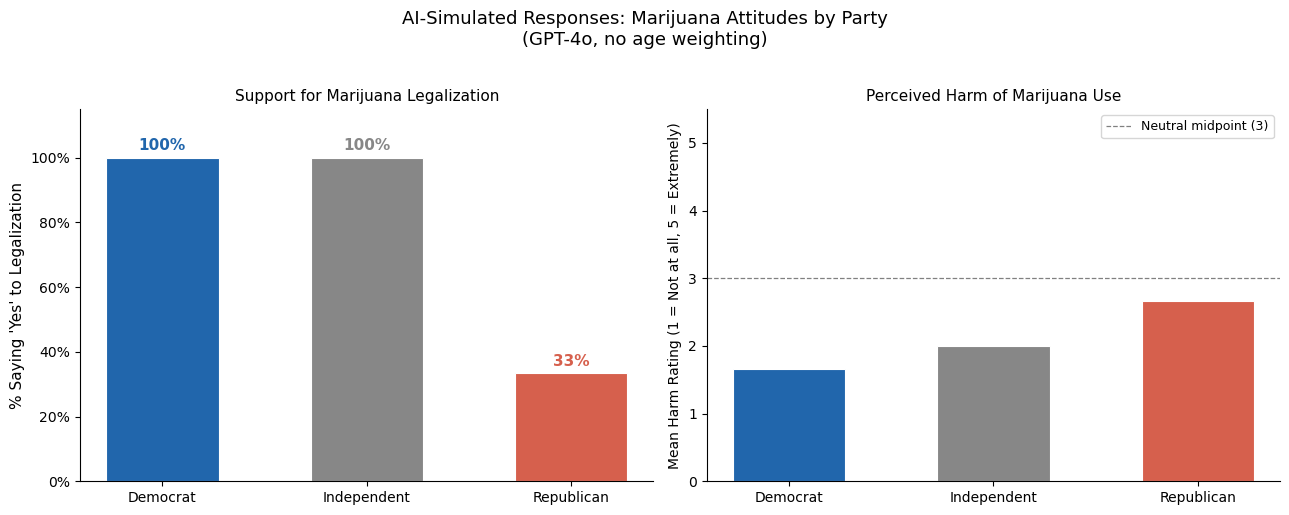

Figure saved as: ai_marijuana_by_party.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Color scheme matching political convention
party_colors = {
    "Democrat":    "#2166ac",  # Blue
    "Republican":  "#d6604d",  # Red
    "Independent": "#878787"   # Gray
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "AI-Simulated Responses: Marijuana Attitudes by Party\n"
    "(GPT-4o, no age weighting)",
    fontsize=13, y=1.02
)

# ── Left panel: % supporting legalization ────────────────────────────────────
ax0 = axes[0]
bars = ax0.bar(
    support_by_party["party"],
    support_by_party["pct_support_ai"],
    color=[party_colors[p] for p in support_by_party["party"]],
    edgecolor="white", linewidth=0.8, width=0.55
)
# Add percentage labels on each bar
for bar, val in zip(bars, support_by_party["pct_support_ai"]):
    ax0.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{val:.0f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
        color=party_colors[support_by_party.iloc[list(bars).index(bar)]["party"]]
    )
ax0.set_ylim(0, 115)
ax0.set_ylabel("% Saying 'Yes' to Legalization", fontsize=11)
ax0.set_title("Support for Marijuana Legalization", fontsize=11)
ax0.spines[["top", "right"]].set_visible(False)
ax0.yaxis.set_major_formatter(mtick.PercentFormatter())

# ── Right panel: mean harm rating ────────────────────────────────────────────
harm_by_party = df_clean.groupby("party")["marijuana_harm"].mean().reset_index()
ax1 = axes[1]
ax1.bar(
    harm_by_party["party"],
    harm_by_party["marijuana_harm"],
    color=[party_colors[p] for p in harm_by_party["party"]],
    edgecolor="white", linewidth=0.8, width=0.55
)
ax1.axhline(3, color="gray", linestyle="--", linewidth=0.9, label="Neutral midpoint (3)")
ax1.set_ylim(0, 5.5)
ax1.set_ylabel("Mean Harm Rating (1 = Not at all, 5 = Extremely)", fontsize=10)
ax1.set_title("Perceived Harm of Marijuana Use", fontsize=11)
ax1.legend(fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("ai_marijuana_by_party.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as: ai_marijuana_by_party.png")

### Why Does GPT-4o Give 100% Support for Democrats and Independents?

This result usually does **not** mean the model is "discovering the true population value."  
It usually means the survey setup is making the model treat each subgroup as a very simple prototype.

In this example, each agent only has a small number of meaningful traits:

- `party`
- `age_group`

So when GPT-4o sees an agent such as:

- Democrat, 18–34
- Democrat, 35–54
- Independent, 18–34

it may map that profile to a very stable default judgment.

For marijuana legalization, the model likely associates:
- Democrats with support
- Independents with support
- Republicans with more mixed or lower support

Because the prompt is short and the trait information is sparse, the model may produce the same answer again and again for the same subgroup.

### Main reason

The model is not seeing many distinct individuals.  
It is seeing a few repeated demographic categories.

So instead of simulating many people, it is effectively answering as a **subgroup stereotype** or **prototype**.

That is why all Democrat agents may say `"Yes"` and all Independent agents may also say `"Yes"`.

### Why adding more agents did not fix it

Adding more agents only increases the number of rows.  
It does **not** increase variation if those agents all have the same traits.

For example, these two agents are almost identical from the model's perspective:

- `Democrat_18-34_1`
- `Democrat_18-34_10`

The `persona_id` is useful for tracking rows, but it does not add social meaning.  
It does not tell the model that one person is religious, one is urban, one uses marijuana medically, or one is more conservative.

So the model keeps giving nearly the same answer.

### Why this happens especially for yes/no questions

A yes/no item is a narrow decision task.  
The model often picks the most likely category for that subgroup and stays there.

That makes outputs look very deterministic.

If the question were more open-ended, or if the agents had richer profiles, you would usually see more variation.

### Why the harm question also clusters

The same logic applies to the harm scale.

If the model has a stable internal mapping such as:
- Democrats → lower perceived harm
- Republicans → moderate or higher perceived harm
- Independents → somewhat lower harm

then repeated agents in the same subgroup will often land on the same scale point, such as `2` or `3`.

### What this result really means

This result is better interpreted as:

> The model is producing a stable subgroup-level pattern.

It is **not** strong evidence that the model is reproducing real individual-level survey variation.

### How to get less deterministic or more realistic results

To create more realistic variation, you need more meaningful traits within each subgroup.  
Examples include:

- gender
- education
- religiosity
- ideology
- urban or rural residence
- prior marijuana use
- family exposure to medical marijuana
- trust in institutions

These traits create real within-group differences.

For example, two Democrat agents may differ if one is:
- young
- urban
- low religiosity
- college educated

and the other is:
- older
- rural
- high religiosity
- no college

Without those extra dimensions, the model has little reason to vary its answer.

Original support by party
         party  pct_support_ai
0     Democrat      100.000000
1  Independent      100.000000
2   Republican       33.333333

Fixed support by party
         party  pct_support_ai
0     Democrat       76.000000
1  Independent       72.463768
2   Republican       20.512821


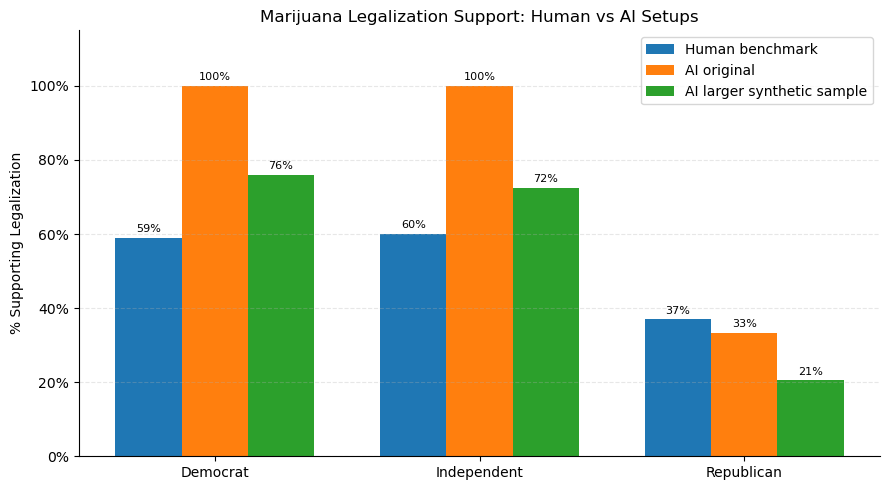


Original synthetic sample size: 9
Fixed synthetic sample size: 74
MAE original setup: 28.2 percentage points
MAE larger synthetic sample: 15.3 percentage points


In [15]:
from edsl import Agent, AgentList, Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

demographic_agents_orig = AgentList(
    Agent(traits={"party": party, "age_group": age})
    for party in ["Democrat", "Republican", "Independent"]
    for age in ["18-34", "35-54", "55+"]
)

orig_results = (
    two_q_survey
    .by(demographic_agents_orig)
    .by(Model("gpt-4o"))
    .run(
        n=5, # One profile is going to be run multiple times to get a distribution of responses
        remote_inference_description="Original setup: party + age only" 
    )
)

cell_counts_fix = {
    ("Democrat", "18-34", "Female", "College", "liberal", "low", "urban"): 6, # 6 is the the number of agents we are copying in synthetic sample for each demographic profile
    ("Democrat", "18-34", "Male", "No college", "moderate", "medium", "suburban"): 4,
    ("Democrat", "35-54", "Female", "College", "moderate", "medium", "suburban"): 5,
    ("Democrat", "35-54", "Male", "No college", "conservative Democrat", "high", "rural"): 3,
    ("Democrat", "55+", "Female", "No college", "conservative Democrat", "high", "rural"): 4,
    ("Democrat", "55+", "Male", "College", "moderate", "medium", "small town"): 3,

    ("Republican", "18-34", "Female", "College", "moderate Republican", "medium", "suburban"): 4,
    ("Republican", "18-34", "Male", "No college", "conservative", "high", "rural"): 5,
    ("Republican", "35-54", "Female", "No college", "conservative", "high", "rural"): 5,
    ("Republican", "35-54", "Male", "College", "moderate Republican", "medium", "suburban"): 3,
    ("Republican", "55+", "Female", "No college", "very conservative", "high", "rural"): 4,
    ("Republican", "55+", "Male", "No college", "very conservative", "high", "rural"): 5,

    ("Independent", "18-34", "Female", "College", "liberal-leaning", "low", "urban"): 5,
    ("Independent", "18-34", "Male", "Some college", "moderate", "medium", "suburban"): 4,
    ("Independent", "35-54", "Female", "Some college", "moderate", "medium", "suburban"): 4,
    ("Independent", "35-54", "Male", "No college", "conservative-leaning", "medium", "small town"): 3,
    ("Independent", "55+", "Female", "No college", "conservative-leaning", "medium", "small town"): 4,
    ("Independent", "55+", "Male", "College", "moderate", "medium", "suburban"): 3,
}

fix_agents = []
for (party, age_group, gender, education, ideology, religiosity, urbanicity), n_people in cell_counts_fix.items():
    for i in range(n_people):
        fix_agents.append(
            Agent(
                traits={
                    "party": party,
                    "age_group": age_group,
                    "gender": gender,
                    "education": education,
                    "ideology": ideology,
                    "religiosity": religiosity,
                    "urbanicity": urbanicity,
                    "persona_id": f"{party}_{age_group}_{gender}_{education}_{i+1}"
                }
            )
        )

demographic_agents_fix = AgentList(fix_agents)

fix_results = (
    two_q_survey
    .by(demographic_agents_fix)
    .by(Model("gpt-4o", temperature=1.0))
    .run(
        n=3,
        remote_inference_description="Fix: larger synthetic sample + richer traits"
    )
)

df_orig = orig_results.to_pandas().rename(columns={
    "agent.party": "party",
    "agent.age_group": "age_group",
    "answer.marijuana_legal": "marijuana_legal",
    "answer.marijuana_harm": "marijuana_harm"
})

df_fix = fix_results.to_pandas().rename(columns={
    "agent.party": "party",
    "agent.age_group": "age_group",
    "agent.gender": "gender",
    "agent.education": "education",
    "agent.ideology": "ideology",
    "agent.religiosity": "religiosity",
    "agent.urbanicity": "urbanicity",
    "answer.marijuana_legal": "marijuana_legal",
    "answer.marijuana_harm": "marijuana_harm"
})

support_orig = (
    df_orig.groupby("party")["marijuana_legal"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="pct_support_ai")
)

support_fix = (
    df_fix.groupby("party")["marijuana_legal"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="pct_support_ai")
)

print("Original support by party")
print(support_orig)
print("\nFixed support by party")
print(support_fix)

human_benchmark = {
    "Democrat": 59,
    "Independent": 60,
    "Republican": 37
}

parties_order = ["Democrat", "Independent", "Republican"]
human_vals = [human_benchmark[p] for p in parties_order]
ai_orig = [support_orig.set_index("party").loc[p, "pct_support_ai"] for p in parties_order]
ai_fix = [support_fix.set_index("party").loc[p, "pct_support_ai"] for p in parties_order]

x = np.arange(len(parties_order))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

bars_human = ax.bar(x - w, human_vals, w, label="Human benchmark")
bars_orig = ax.bar(x, ai_orig, w, label="AI original")
bars_fix = ax.bar(x + w, ai_fix, w, label="AI larger synthetic sample")

for bars in [bars_human, bars_orig, bars_fix]:
    for b in bars:
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 1,
            f"{b.get_height():.0f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(x)
ax.set_xticklabels(parties_order)
ax.set_ylim(0, 115)
ax.set_ylabel("% Supporting Legalization")
ax.set_title("Marijuana Legalization Support: Human vs AI Setups")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

mae_orig = np.mean([abs(h - a) for h, a in zip(human_vals, ai_orig)])
mae_fix = np.mean([abs(h - a) for h, a in zip(human_vals, ai_fix)])

print(f"\nOriginal synthetic sample size: {len(demographic_agents_orig)}")
print(f"Fixed synthetic sample size: {len(demographic_agents_fix)}")
print(f"MAE original setup: {mae_orig:.1f} percentage points")
print(f"MAE larger synthetic sample: {mae_fix:.1f} percentage points")

---
## 7. Complete Assignment Walkthrough — Pew 2024 Marijuana Example

This section is a **full, runnable demonstration of the assignment** using the
recommended default source.  Run every cell in order and you will have produced
all five components required in your written report.

**Source used:** Pew Research Center (2024), "Most Americans Favor Legalizing
Marijuana for Medical, Recreational Use" — March 26, 2024.

> **Estimated cost:** ≈ 30–50 Expected Parrot credits for the complete
> walkthrough (8 agents × 1 model × 1 question).


### Step 1: Document Your Source (Report Section 1)

Think about a table like this **before you write any code**.  Everything in it
should come straight from the report cover page, methodology note, and topline.

| Field | This example |
|---|---|
| Organisation | Pew Research Center |
| Report title | Most Americans Favor Legalizing Marijuana for Medical, Recreational Use |
| Publication date | March 26, 2024 |
| Survey dates | January 16–21, 2024 |
| Population | U.S. adults |
| Sample size | *n* = 5,140 |
| Subgroup breakdowns used | Party ID (Rep/Lean Rep, Dem/Lean Dem); Age (18–29, 30–49, 50–64, 65+) |
| Benchmark figure | % saying marijuana should be legal for *both* medical and recreational use |

---

**How to find the exact question wording:**  
Always quote from the **topline questionnaire PDF**! 
The 2024 Pew report concept is:

> "Do you think the use of marijuana should be legal for recreational and  
> medical use, legal for medical use only, or should it not be legal?"

For comparison, the 2013 Pew topline (Q.85) gives an older binary version:

> "Do you think the use of marijuana should be made legal, or not?" 
> (Responses: Yes, legal / No, illegal / DK-Ref)

We use the **2024 three-option version** because it matches the benchmark chart
we are replicating.


### Step 2: Define the Human Benchmark (Report Section 3)

In [ ]:
import pandas as pd

# ── Human benchmark: Pew Research Center, 2024 ───────────────────────────
# Source: "Most Americans Favor Legalizing Marijuana for Medical, Recreational Use"
#         March 26, 2024; n = 5,140 U.S. adults; survey Jan 16-21, 2024
# Figure: % within each group for each response option

# ── By party ─────────────────────────────────────────────────────────────
party_bench = pd.DataFrame({
    "group":         ["Rep/Lean Rep", "Dem/Lean Dem"], # Pew's 3-category party ID collapsed into 2 for simplicity
                    # Stands for "Republican or Independent but lean Republican" and "Democrat or Independent but lean Democrat"
    "both":          [42, 72],   # legal for medical AND recreational
    "medical_only":  [40, 22],   # legal for medical use only
    "not_legal":     [17,  5],   # should not be legal
})

# ── By age ────────────────────────────────────────────────────────────────
age_bench = pd.DataFrame({
    "group":         ["18-29", "30-49", "50-64", "65+"],
    "both":          [71, 62, 50, 43],
    "medical_only":  [22, 27, 37, 42],
    "not_legal":     [ 6, 11, 13, 14],
})

print("Human benchmark (Pew Research Center, 2024)")
print("  Overall: 57% both uses legal | 32% medical only | 11% not legal")
print()
print("By party:")
print(party_bench.to_string(index=False))
print()
print("By age group:")
print(age_bench.to_string(index=False))


Human benchmark (Pew Research Center, 2024)
  Overall: 57% both uses legal | 32% medical only | 11% not legal

By party:
       group  both  medical_only  not_legal
Rep/Lean Rep    42            40         17
Dem/Lean Dem    72            22          5

By age group:
group  both  medical_only  not_legal
18-29    71            22          6
30-49    62            27         11
50-64    50            37         13
  65+    43            42         14


### Step 3: Design Your Agents (Report Section 2)

**Rule:** only include traits that your benchmark source actually reports
breakdowns for.  The Pew 2024 report gives breakdowns by **party** and **age**,
so those are the two dimensions we vary.

**Grid design:** 2 parties × 4 age groups = **8 agents, 3 runs each = 24 responses**

| | 18–29 | 30–49 | 50–64 | 65+ |
|---|---|---|---|---|
| **Rep/Lean Rep** | ✓ | ✓ | ✓ | ✓ |
| **Dem/Lean Dem** | ✓ | ✓ | ✓ | ✓ |

> **⚠️ Why you should always use `n ≥ 3`**  
> LLMs carry strong political stereotypes.  A single Democrat agent asked
> about marijuana will almost always say "Yes" — giving you 100%, not 72%.
> Running each agent **3 times** and averaging produces a more realistic spread
> because the model occasionally expresses uncertainty or nuance.  For the
> assignment, `n=3` is a reasonable minimum; `n=5` gives smoother estimates.

> **For your report:** describe this grid in Section 2 and explain *why* each
> trait was chosen.  One sentence per trait is enough.


In [26]:
from edsl import Agent, AgentList

# 2 parties × 4 age groups = 8 agents
parties = [
    {"label": "Rep/Lean Rep", "party": "Republican", "lean": "Republican"},
    {"label": "Dem/Lean Dem", "party": "Democrat",   "lean": "Democrat"},
]
age_groups = ["18-29", "30-49", "50-64", "65+"]

agents = AgentList([
    Agent(traits={
        "party":       p["party"],
        "party_lean":  p["lean"],
        "party_label": p["label"],
        "age_group":   age,
        "persona": (
            f"You are a {age}-year-old {p['party']} who leans {p['lean']}. "
            "You are a U.S. adult answering a survey question about marijuana policy."
        )
    })
    for p in parties
    for age in age_groups
])

print(f"Created {len(agents)} agents:")
for a in agents:
    print(f"  party_label={a.traits['party_label']!r:20s}  age_group={a.traits['age_group']!r}")


Created 8 agents:
  party_label='Rep/Lean Rep'        age_group='18-29'
  party_label='Rep/Lean Rep'        age_group='30-49'
  party_label='Rep/Lean Rep'        age_group='50-64'
  party_label='Rep/Lean Rep'        age_group='65+'
  party_label='Dem/Lean Dem'        age_group='18-29'
  party_label='Dem/Lean Dem'        age_group='30-49'
  party_label='Dem/Lean Dem'        age_group='50-64'
  party_label='Dem/Lean Dem'        age_group='65+'


### Step 4: Run the Survey

In [ ]:
from edsl import QuestionMultipleChoice, Survey, Model

# ── Exact question wording (Pew 2024 concept) ─────────────────────────────
q_marijuana = QuestionMultipleChoice(
    question_name="marijuana_legal",
    question_text=(
        "Do you think the use of marijuana should be legal for recreational "
        "and medical use, legal for medical use only, or should it not be legal?"
    ),
    question_options=[
        "Legal for both medical and recreational use",
        "Legal for medical use only",
        "Should not be legal"
    ]
)

# ── Run with n=3 — each agent answers 3 times, then we average ────────────
# This avoids the "100% Democrat / 0% Republican" problem caused by
# LLM stereotyping when n=1.  With n=3, each cell has 3 responses to average.
# Total calls: 8 agents × 1 question × 3 runs = 24 API calls (~30-50 credits)

# THIS SENARIO ONLY because we are using a single question and a small number of agents — 
# for larger surveys, you would want to use more agents and fewer runs per agent to keep costs manageable.

pew_results = (
    Survey(questions=[q_marijuana])
    .by(agents)
    .by(Model("gpt-4o"))
    .run(
        n=3,   # <── run each agent 3 times
        remote_inference_description="Section 8 — Pew 2024 marijuana walkthrough (n=3)"
    )
)

pew_results.select("party_label", "age_group", "marijuana_legal").print()


agent.party_label,agent.age_group,answer.marijuana_legal
Rep/Lean Rep,18-29,Legal for medical use only
Rep/Lean Rep,18-29,Legal for both medical and recreational use
Rep/Lean Rep,18-29,Legal for medical use only
Rep/Lean Rep,30-49,Legal for medical use only
Rep/Lean Rep,30-49,Legal for medical use only
Rep/Lean Rep,30-49,Legal for medical use only
Rep/Lean Rep,50-64,Legal for medical use only
Rep/Lean Rep,50-64,Legal for medical use only
Rep/Lean Rep,50-64,Legal for medical use only
Rep/Lean Rep,65+,Legal for medical use only


### Step 5: Compare AI vs Human Results (Report Section 3)

In [28]:
# ── Convert to DataFrame (n=3 means multiple rows per agent) ─────────────
df = pew_results.to_pandas().rename(columns={
    "agent.party_label":      "party_label",
    "agent.age_group":        "age_group",
    "answer.marijuana_legal": "ai_response"
})

BOTH = "Legal for both medical and recreational use"

# With n=3 there are 3 rows per agent; groupby averages across all 3 runs
# ── Comparison by PARTY ───────────────────────────────────────────────────
party_ai = (
    df.groupby("party_label")["ai_response"]
    .apply(lambda x: (x == BOTH).mean() * 100)
    .reset_index()
    .rename(columns={"party_label": "group", "ai_response": "ai_both"})
)
party_cmp = party_bench.rename(columns={"both": "human_both"}).merge(party_ai, on="group")
party_cmp["abs_error"] = (party_cmp["human_both"] - party_cmp["ai_both"]).abs()

print("── By party ──────────────────────────────────────────────────────────")
print(party_cmp[["group","human_both","ai_both","abs_error"]]
      .rename(columns={"group":"Party","human_both":"Human %","ai_both":"AI %",
                        "abs_error":"Abs Error (pp)"}).to_string(index=False))
print(f"  MAE (party) = {party_cmp['abs_error'].mean():.1f} pp")

# ── Comparison by AGE ─────────────────────────────────────────────────────
age_ai = (
    df.groupby("age_group")["ai_response"]
    .apply(lambda x: (x == BOTH).mean() * 100)
    .reset_index()
    .rename(columns={"age_group": "group", "ai_response": "ai_both"})
)
age_cmp = age_bench.rename(columns={"both": "human_both"}).merge(age_ai, on="group")
age_cmp["abs_error"] = (age_cmp["human_both"] - age_cmp["ai_both"]).abs()

print()
print("── By age group ──────────────────────────────────────────────────────")
print(age_cmp[["group","human_both","ai_both","abs_error"]]
      .rename(columns={"group":"Age","human_both":"Human %","ai_both":"AI %",
                        "abs_error":"Abs Error (pp)"}).to_string(index=False))
print(f"  MAE (age)   = {age_cmp['abs_error'].mean():.1f} pp")

print()
print("Guide: MAE < 10 pp = good match | 10–20 pp = moderate | > 20 pp = discuss why")


── By party ──────────────────────────────────────────────────────────
       Party  Human %       AI %  Abs Error (pp)
Rep/Lean Rep       42   8.333333       33.666667
Dem/Lean Dem       72 100.000000       28.000000
  MAE (party) = 30.8 pp

── By age group ──────────────────────────────────────────────────────
  Age  Human %      AI %  Abs Error (pp)
18-29       71 66.666667        4.333333
30-49       62 50.000000       12.000000
50-64       50 50.000000        0.000000
  65+       43 50.000000        7.000000
  MAE (age)   = 5.8 pp

Guide: MAE < 10 pp = good match | 10–20 pp = moderate | > 20 pp = discuss why


### Step 6: Visualize — AI vs Human Side-by-Side (Report Section 3)

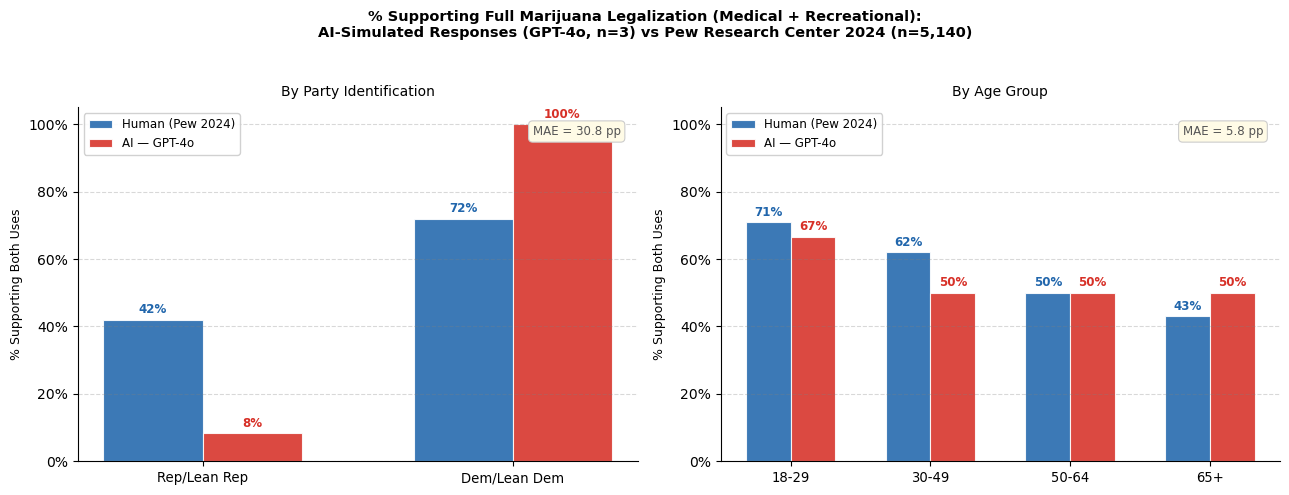

Saved as pew2024_ai_vs_human.png — use this as Figure 1 in Report Section 3.

How to read this chart:
  • Blue bars = real survey respondents (Pew 2024)
  • Red bars  = AI agents (GPT-4o, averaged over 3 runs per cell)
  • The closer the red bar is to the blue, the better the AI replicates human opinion.
  • MAE = Mean Absolute Error across all groups in that panel


In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ─────────────────────────────────────────────────────────────────────────
# Figure 1 — Side-by-side: AI (GPT-4o) vs Human (Pew 2024)
# Two panels: left = by party, right = by age
# Blue bars = real human data from Pew 2024
# Red  bars = AI-simulated responses (GPT-4o, n=3 per agent)
# ─────────────────────────────────────────────────────────────────────────

HUMAN_COLOR = "#2166ac"   # blue  = real humans
AI_COLOR    = "#d73027"   # red   = AI agents
W = 0.32

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "% Supporting Full Marijuana Legalization (Medical + Recreational):\n"
    "AI-Simulated Responses (GPT-4o, n=3) vs Pew Research Center 2024 (n=5,140)",
    fontsize=10.5, fontweight="bold"
)

def draw_comparison(ax, cmp_df, x_labels, title, note=None):
    x = np.arange(len(x_labels))
    bh = ax.bar(x - W/2, cmp_df["human_both"], W,
                label="Human (Pew 2024)", color=HUMAN_COLOR, alpha=0.88,
                linewidth=0.8, edgecolor="white")
    ba = ax.bar(x + W/2, cmp_df["ai_both"],    W,
                label="AI — GPT-4o",     color=AI_COLOR,    alpha=0.88,
                linewidth=0.8, edgecolor="white")

    # Value labels
    for bar, color in [(bh, HUMAN_COLOR), (ba, AI_COLOR)]:
        for b in bar:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.0,
                    f"{b.get_height():.0f}%",
                    ha="center", va="bottom", fontsize=8.5, color=color, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=9.5)
    ax.set_ylim(0, 105)
    ax.set_ylabel("% Supporting Both Uses", fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title, fontsize=10, pad=8)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
    ax.spines[["top", "right"]].set_visible(False)

    # MAE badge
    mae_val = cmp_df["abs_error"].mean()
    ax.text(0.97, 0.95, f"MAE = {mae_val:.1f} pp",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color="#555",
            bbox=dict(boxstyle="round,pad=0.35", fc="#fffbe6", ec="#ccc", lw=0.8))

draw_comparison(ax=axes[0],
                cmp_df=party_cmp,
                x_labels=party_cmp["group"].tolist(),
                title="By Party Identification")

draw_comparison(ax=axes[1],
                cmp_df=age_cmp,
                x_labels=age_cmp["group"].tolist(),
                title="By Age Group")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("pew2024_ai_vs_human.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as pew2024_ai_vs_human.png — use this as Figure 1 in Report Section 3.")
print()
print("How to read this chart:")
print("  • Blue bars = real survey respondents (Pew 2024)")
print("  • Red bars  = AI agents (GPT-4o, averaged over 3 runs per cell)")
print("  • The closer the red bar is to the blue, the better the AI replicates human opinion.")
print("  • MAE = Mean Absolute Error across all groups in that panel")


### Step 7: Write the Discussion (Report Section 4)

Copy the scaffold below and fill in the bracketed values from your tables.

---

**Paragraph 1 — Party alignment:**

> GPT-4o [matched / overestimated / underestimated] human support for full
> marijuana legalization among [Democratic / Republican] respondents by
> approximately [X] percentage points (AI: [Y]%, Human benchmark: [Z]%).
> Among [the other party] the gap was [larger / smaller / similar] ([X2] pp).
> The model [did / did not] correctly reproduce the direction of the partisan
> gap — Democrats more supportive than Republicans — which is the key pattern
> in the Pew 2024 report.

**Paragraph 2 — Age alignment:**

> Across age groups, the AI [captured / reversed / flattened] the trend toward
> lower support among older adults.  The largest discrepancy was in the
> [youngest / oldest] age group ([X] pp), possibly because [LLM training data
> skews toward younger online voices / the model lacks genuine age-based
> reasoning about policy attitudes].

**Paragraph 3 — Limitations and next steps:**

> This replication has several limitations.  First, each demographic cell
> contains only one agent, so the AI "response rate" is binary rather than a
> true proportion.  Running 5–10 agents per cell and averaging would produce
> more stable estimates.  Second, the persona may be underspecified — adding
> traits such as [education, region, religiosity] might improve alignment.
> Third, AI responses were elicited without the survey context real respondents
> experienced.  Future work could test whether adding preceding questions as
> context changes the distribution.

---

> **Appendix reminder:** paste `df.to_string()` output, note the model string
> (`"gpt-4o"`), and record the `remote_inference_description` value so your
> results are traceable on the Coop dashboard.


### Note on Credits
The Section 7 walkthrough (8 agents × 1 question × 3 runs = 24 API calls) uses approximately **20–40 Expected Parrot credits** (~\$0.02–0.04).  Your free account includes **2,500 credits**, so you can run the entire notebook many times over.  Monitor usage at [expectedparrot.com](https://www.expectedparrot.com).

---
## 8. References

### Data Sources

**General Social Survey (GSS)**  
Smith, Tom W., Michael Davern, Jeremy Freese, and Stephen L. Morgan. *General Social Surveys, 1972-2022* [machine-readable data file]. Principal Investigator, Tom W. Smith; Co-Principal Investigators, Michael Davern, Jeremy Freese, and Stephen Morgan. Chicago: NORC at the University of Chicago, 2023.  
Access: https://gss.norc.org/ | Data explorer: https://gssdataexplorer.norc.org/

**Pew Research Center**  
Pew Research Center. (2023). *News Platform Fact Sheet.* Journalism & Media.  
Access: https://www.pewresearch.org/journalism/fact-sheet/news-platform-fact-sheet/

**American National Election Studies (ANES)**  
American National Election Studies. (2021). *ANES 2020 Time Series Study Full Release* [dataset and documentation].  
Access: https://electionstudies.org/data-center/2020-time-series-study/

**Monitoring the Future**  
Johnston, L.D., Miech, R.A., O'Malley, P.M., Bachman, J.G., Schulenberg, J.E., & Patrick, M.E. (2023). *Monitoring the Future national survey results on drug use: 1975-2022.* Ann Arbor: Institute for Social Research, University of Michigan.  
Access: https://monitoringthefuture.org/

---

### EDSL Software

**Expected Parrot (2024).** *EDSL: Expected Parrot Domain-Specific Language* [software].  
GitHub: https://github.com/expectedparrot/edsl  
Documentation: https://docs.expectedparrot.com/  
Install: `pip install edsl`

---

### Key Academic References on AI Survey Simulation

**Argyle, L.P., Busby, E., Fulda, N., Gubler, J., Rytting, C., & Wingate, D. (2023).** Out of One, Many: Using Language Models to Simulate Human Samples. *Political Analysis, 31*(3), 337–351.  
This paper coined the term "silicon sampling" and provided the first systematic evaluation of whether LLMs can replicate human survey demographics. *(Foundational reference for your assignment.)*

**Santurkar, S., Durmus, E., Ladd, F., Lee, E., Liang, P., & Hashimoto, T. (2023).** Whose Opinions Do Language Models Reflect? *Proceedings of the 40th International Conference on Machine Learning (ICML 2023).*  
Evaluated alignment between LLM responses and US public opinion across demographics. Found consistent demographic skews.

**Bisbee, J., Clinton, J., Dorff, C., Kenkel, B., & Larson, J. (2023).** Synthetic Replacements for Human Survey Data? The Perils of Large Language Models. *Political Analysis.*  
A cautionary paper: finds that LLMs often fail to reproduce the *magnitude* of opinion gaps even when they reproduce the *direction*.

**Hetherington, M.J. & Rudolph, T.J. (2015).** *Why Washington Won't Work: Polarization, Political Trust, and the Governing Crisis.* University of Chicago Press.  
Background reading on partisan differences in government trust (the context for the ANES trust question used in Section 6).

---

### A Note on Citing AI-Generated Data

<mark> When you include AI-simulated results in your report, always:<mark>
1. State which model you used (e.g., GPT-4o, accessed March 2025)
2. State the EDSL version (`import edsl; edsl.__version__`)
3. Report your temperature setting and any other model parameters
4. Note that AI responses may vary across runs unless temperature=0.0
5. Never present AI-generated figures as human survey data
